# **Table of Contents**
* [**Table of Contents**](#**table-of-contents**)
  * [Imports](#imports)
  * [Clean Poverty Data](#clean-poverty-data)
  * [Clean Income Data](#clean-income-data)
  * [Clean Housing Age Data](#clean-housing-age-data)
  * [Clean Median Gross Rent](#clean-median-gross-rent)
  * [Clean Home Value](#clean-home-value)
  * [Clean Rent Burden](#clean-rent-burden)
  * [Clean Active Permits](#clean-active-permits)
    * [GeoPandas - Neighborhoods](#geopandas---neighborhoods)
    * [GeoDataFrame - Neighborhood Permits](#geodataframe---neighborhood-permits)
    * [GeoDataFrame - Tract Permits](#geodataframe---tract-permits)
  * [Groupby and Merging](#groupby-and-merging)
* [TOC Generator](#toc-generator)


## Imports


In [38]:
import pandas as pd
from pathlib import Path
import geopandas as gpd

Rather than spend a ton of time I used AI to help below. We just cleaned up what you already had making a clean reusable function to do what you did rather than repeating code over and over. We also took out all the things that become clutter ex being .head() .shape etc. That is great for initial building but it never ends up in production. 

# Clean path 
Got rid of the full paths to us dynamic paths 

In [39]:
BASE_DIR = Path.cwd()

RAW_DIR = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# REUSABLE CLEANING FUNCTION
- Made it DRY so that you are not repeating the same things over and over. 
- Removed all .head() and .info etc. 
  - Great for when working but remove when done as it just adds noise and makes files harder to look at. 

In [40]:
def clean_standard_acs_data(
    file_name: str, 
    output_name: str, 
    value_col_name: str,
    raw_dir: Path,
    processed_dir: Path
) -> pd.DataFrame:
    """
    Cleans and standardizes American Community Survey (ACS) datasets.
    
    Reads a raw ACS CSV file, removes margin-of-error columns, transposes 
    the dataset, standardizes header names, extracts numeric Census Tract 
    identifiers, and exports the cleaned data to the processed directory.

    Args:
        file_name (str): The filename of the raw CSV to read.
        output_name (str): The desired filename for the cleaned CSV output.
        value_col_name (str): The standardized name to assign to the target 
            data column (e.g., 'MEDIAN_GROSS_RENT' or 'TOTAL').
        raw_dir (Path): The directory path containing the raw data files.
        processed_dir (Path): The directory path where cleaned data is saved.

    Returns:
        pd.DataFrame: The cleaned dataset as a pandas DataFrame.
    """
    input_path = raw_dir / file_name
    output_path = processed_dir / output_name

    df = pd.read_csv(input_path)

    error_columns = df.columns[df.columns.str.contains('Margin of Error', na=False)]
    df = df.drop(columns=error_columns)

    df = df.transpose().reset_index()
    df = df.rename(columns=df.iloc[0]).drop(df.index[0])

    df.columns = df.columns.str.strip()
    
    target_renames = {
        'Total:': 'TOTAL',
        'Median gross rent': value_col_name,
        'Median value': value_col_name,
        df.columns[0]: 'TRACT'
    }
    df = df.rename(columns=target_renames)

    df['TRACT'] = df['TRACT'].str.extract(r'Census Tract ([\d.]+)')

    df.to_csv(output_path, index=True)
    print(f"Successfully processed and saved {output_name}")

    return df

## cool thing
When you add a doc string you can use the `?` to see the documentation you provided so you dont have to go back and read the code to see how to run it etc. 

In [71]:
clean_standard_acs_data?

Signature:
clean_standard_acs_data(
    file_name: str,
    output_name: str,
    value_col_name: str,
    raw_dir: pathlib.Path,
    processed_dir: pathlib.Path,
) -> pandas.core.frame.DataFrame
Docstring:
Cleans and standardizes American Community Survey (ACS) datasets.

Reads a raw ACS CSV file, removes margin-of-error columns, transposes 
the dataset, standardizes header names, extracts numeric Census Tract 
identifiers, and exports the cleaned data to the processed directory.

Args:
    file_name (str): The filename of the raw CSV to read.
    output_name (str): The desired filename for the cleaned CSV output.
    value_col_name (str): The standardized name to assign to the target 
        data column (e.g., 'MEDIAN_GROSS_RENT' or 'TOTAL').
    raw_dir (Path): The directory path containing the raw data files.
    processed_dir (Path): The directory path where cleaned data is saved.

Returns:
    pd.DataFrame: The cleaned dataset as a pandas DataFrame.
File:      /var/folders/2d/yt

# 1. CLEAN STANDARD ACS DATASETS
using our cleaning functions above to process all the data at once.

In [41]:
print("Processing standard ACS datasets...")

df_housing_age = clean_standard_acs_data(
    file_name='acs_2024_jefferson_housing_age_by_tract_b25034.csv',
    output_name='housing_age_clean.csv',
    value_col_name='TOTAL',
    raw_dir=RAW_DIR,
    processed_dir=PROCESSED_DIR
)

df_rent = clean_standard_acs_data(
    file_name='acs_2024_jefferson_median_gross_rent_by_tract_b25064.csv',
    output_name='rent_clean.csv',
    value_col_name='MEDIAN_GROSS_RENT',
    raw_dir=RAW_DIR,
    processed_dir=PROCESSED_DIR
)

df_home_value = clean_standard_acs_data(
    file_name='acs_2024_jefferson_median_home_value_by_tract_b25077.csv',
    output_name='home_value_clean.csv',
    value_col_name='MEDIAN_HOME_VALUE',
    raw_dir=RAW_DIR,
    processed_dir=PROCESSED_DIR
)

df_rent_burden = clean_standard_acs_data(
    file_name='acs_2024_jefferson_rent_burden_by_tract_b25070.csv',
    output_name='rent_burden_clean.csv',
    value_col_name='TOTAL',
    raw_dir=RAW_DIR,
    processed_dir=PROCESSED_DIR
)

Processing standard ACS datasets...
Successfully processed and saved housing_age_clean.csv
Successfully processed and saved rent_clean.csv
Successfully processed and saved home_value_clean.csv
Successfully processed and saved rent_burden_clean.csv


# 2. CLEAN POVERTY DATA (Unique Layout)
- Ideally this is a function as well 

In [42]:

print("Processing Poverty dataset...")
df_poverty = pd.read_csv(
    RAW_DIR / 'acs_2024_jefferson_poverty_by_tract_s1701.csv')
df_poverty = df_poverty[["GEO_ID", "NAME",
                         "S1701_C01_001E", "S1701_C02_001E", "S1701_C03_001E"]]
df_poverty = df_poverty.drop(index=0)

df_poverty = df_poverty.rename(columns={
    "NAME": "TRACT",
    "S1701_C01_001E": "POPULATION",
    "S1701_C02_001E": "BELOW_POVERTY",
    "S1701_C03_001E": "POVERTY_RATE"
})

df_poverty['TRACT'] = df_poverty['TRACT'].str.extract(r'Census Tract ([\d.]+)')
df_poverty.to_csv(PROCESSED_DIR / 'poverty_rate_clean.csv', index=False)
print("Successfully processed and saved poverty_rate_clean.csv")

Processing Poverty dataset...
Successfully processed and saved poverty_rate_clean.csv


# 3. CLEAN INCOME DATA (Unique Layout)
- same here ideally a function 

In [43]:

print("Processing Income dataset...")
df_income = pd.read_csv(
    RAW_DIR / 'acs_2024_jefferson_household_income_by_tract_b19013.csv')
df_income = df_income.rename(columns={
    "Label (Grouping)": "TRACT",
    "Median household income in the past 12 months (in 2024 inflation-adjusted dollars)": "ESTIMATED_MEDIAN_HOUSEHOLD_INCOME"
})

df_income['ESTIMATED_MEDIAN_HOUSEHOLD_INCOME'] = df_income['ESTIMATED_MEDIAN_HOUSEHOLD_INCOME'].shift(
    -1)
df_income = df_income.drop(df_income[df_income['TRACT'].str.contains(
    'Estimate|Margin of Error', na=False)].index)
df_income['TRACT'] = df_income['TRACT'].str.extract(r'Census Tract ([\d.]+)')

df_income.to_csv(PROCESSED_DIR / 'income_clean.csv', index=False)
print("Successfully processed and saved income_clean.csv")



Processing Income dataset...
Successfully processed and saved income_clean.csv


# 4. CLEAN PERMIT DATA 
- same here 

In [44]:

print("Processing Active Permits dataset...")
df_permits = pd.read_csv(
    RAW_DIR / 'louisville_active_construction_permits.csv')

df_permits["ZIPCODE"] = df_permits["ZIPCODE"].astype(str).str.split("-").str[0]
df_permits = df_permits[['ISSUE_DATE', 'ADDRESS', 'CITY',
                         'ZIPCODE', 'LATITUDE', 'LONGITUDE', 'DISTRICT', 'NEIGHBORHOOD']]

# Convert to datetime and filter for 2024 efficiently
df_permits['ISSUE_DATE'] = pd.to_datetime(
    df_permits['ISSUE_DATE'], errors='coerce')
df_permits = df_permits[df_permits['ISSUE_DATE'].dt.year == 2024]

df_permits.to_csv(PROCESSED_DIR / 'permits_2024_clean.csv', index=False)
print("Successfully processed and saved permits_2024_clean.csv")
print("All files processed successfully!")

Processing Active Permits dataset...
Successfully processed and saved permits_2024_clean.csv
All files processed successfully!


### GeoPandas - Neighborhoods


In [45]:
# Using geopandas to establish neighborhood boundaries
neighborhoods = gpd.read_file(
    "../Curtis/data/raw/louisville_neighborhoods.shp")

neighborhoods.head()

,FID,OBJECTID,NH_CODE,NH_NAME,SHAPE_AREA,SHAPE_LEN,Shape__Are,Shape__Len,geometry
0,1,1,99,REMAINDER OF CITY,2.558333e+07,23718.323690,3.862567e+06,9212.878110,"POLYGON ((-9540393.792 4617703.961, -9540402.5..."
1,2,2,53,PORTLAND,7.009830e+07,43851.334658,1.058229e+07,17022.173071,"POLYGON ((-9553463.362 4618611.679, -9553447.4..."
2,3,3,62,SHAWNEE,5.995385e+07,34088.057055,9.049049e+06,13244.602998,"POLYGON ((-9553463.362 4618611.679, -9553429.3..."
3,4,4,12,BROWNSBORO ZORN,2.197732e+07,28060.141437,3.317622e+06,10894.667480,"POLYGON ((-9540393.792 4617703.961, -9540378.4..."
4,5,5,23,CLIFTON HEIGHTS,1.785864e+07,19464.933453,2.695641e+06,7556.792253,"POLYGON ((-9541751.15 4616793.564, -9541693.57..."


In [46]:
neighborhoods.columns

Index(['FID', 'OBJECTID', 'NH_CODE', 'NH_NAME', 'SHAPE_AREA', 'SHAPE_LEN',
       'Shape__Are', 'Shape__Len', 'geometry'],
      dtype='object')

In [47]:
# Coordinate Reference Systems (CRS) to check European Petroleum Survey Group (ESPG) identifier
neighborhoods.crs

<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [48]:
# Set a CRS - only if needed
# EPSG:2246 is Kentucky North
# neighborhoods = neighborhoods.set_crs("EPSG:2246")

In [49]:
# Convert to latitude and logitude - 4326 is commonly used for GPS-like mapping using degrees
neighborhoods = neighborhoods.to_crs("EPSG:4326")

In [50]:
# Check to make sure it worked
neighborhoods.head()

,FID,OBJECTID,NH_CODE,NH_NAME,SHAPE_AREA,SHAPE_LEN,Shape__Are,Shape__Len,geometry
0,1,1,99,REMAINDER OF CITY,2.558333e+07,23718.323690,3.862567e+06,9212.878110,"POLYGON ((-85.70282 38.27046, -85.70289 38.270..."
1,2,2,53,PORTLAND,7.009830e+07,43851.334658,1.058229e+07,17022.173071,"POLYGON ((-85.82022 38.27686, -85.82008 38.276..."
2,3,3,62,SHAWNEE,5.995385e+07,34088.057055,9.049049e+06,13244.602998,"POLYGON ((-85.82022 38.27686, -85.81992 38.276..."
3,4,4,12,BROWNSBORO ZORN,2.197732e+07,28060.141437,3.317622e+06,10894.667480,"POLYGON ((-85.70282 38.27046, -85.70268 38.270..."
4,5,5,23,CLIFTON HEIGHTS,1.785864e+07,19464.933453,2.695641e+06,7556.792253,"POLYGON ((-85.71501 38.26404, -85.71449 38.264..."


<Axes: >

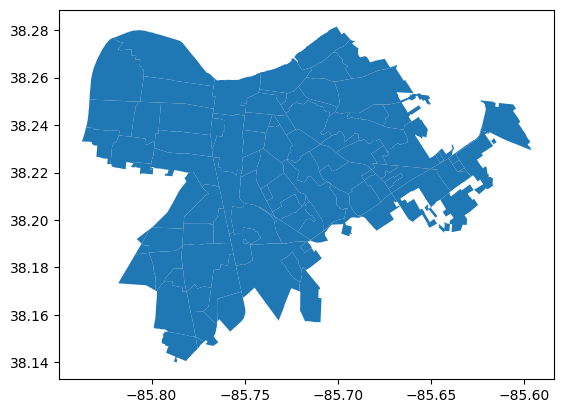

In [51]:
# Check to see if the map works
neighborhoods.plot()

### GeoDataFrame - Neighborhood Permits


In [52]:
# Convert to a GeoDataFrame
gdf_permits = gpd.GeoDataFrame(
    df_permits,
    geometry=gpd.points_from_xy(
        df_permits["LONGITUDE"], df_permits["LATITUDE"]),
    crs="EPSG:4326"
)

In [53]:
# Spatial join to fill in missing Neighborhood data
result_perm_neig = gpd.sjoin(
    gdf_permits, neighborhoods, how="left", predicate="intersects")

In [54]:
# Check results
result_perm_neig[["NEIGHBORHOOD", "NH_NAME"]].head()

,NEIGHBORHOOD,NH_NAME
10595,NaN,NaN
10596,NaN,NaN
10597,NaN,NaN
10598,NaN,NaN
10599,NaN,NaN


In [55]:
# Fill in the missing values
result_perm_neig["NEIGHBORHOOD"] = result_perm_neig["NEIGHBORHOOD"].fillna(
    result_perm_neig["NH_NAME"])

In [56]:
# Check to make sure it worked
result_perm_neig[["NEIGHBORHOOD", "NH_NAME"]].head()

,NEIGHBORHOOD,NH_NAME
10595,NaN,NaN
10596,NaN,NaN
10597,NaN,NaN
10598,NaN,NaN
10599,NaN,NaN


In [57]:
result_perm_neig.isna().sum()

ISSUE_DATE         0
ADDRESS            0
CITY               2
ZIPCODE            0
LATITUDE           2
LONGITUDE          2
DISTRICT           4
NEIGHBORHOOD    2226
geometry           0
index_right     2198
FID             2198
OBJECTID        2198
NH_CODE         2198
NH_NAME         2226
SHAPE_AREA      2198
SHAPE_LEN       2198
Shape__Are      2198
Shape__Len      2198
dtype: int64

In [58]:
result_perm_neig[result_perm_neig["NH_NAME"].isna()][[
    "LATITUDE", "LONGITUDE"]].head()

,LATITUDE,LONGITUDE
10595,38.112770,-85.642772
10596,38.113046,-85.642733
10597,38.113541,-85.642661
10598,38.113555,-85.642964
10599,38.173643,-85.819359


<Axes: >

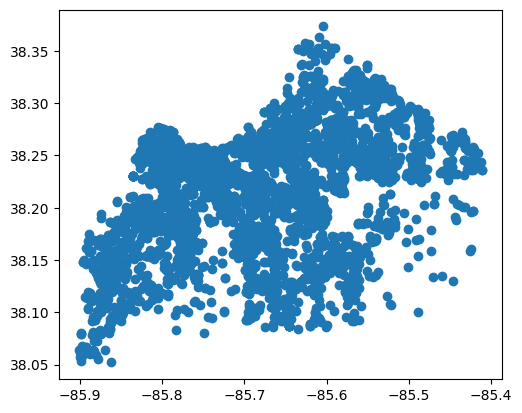

In [59]:
gdf_permits.plot()

In [60]:
# Overall, assigning neighborhoods by lat/long worked, however ~66% of the 2024 permits were issued outside of the neighborhood boundaries it seems.
# Basically, this means this project needs to shift from the neighborhood level to census tracts.
# Only representing a portion of the city that falls into these neighborhoods isn't viable for the project scope.
# Keeping the neighborhood and geopandas work done so far. Maybe it can be useful and/or relatable later.
result_perm_neig["NH_NAME"].isna().mean()

np.float64(0.6632896305125149)

In [61]:
# Output clean file
result_perm_neig.to_csv(
    "../Curtis/data/processed/permits_neighborhoods_clean.csv", index=True)

### GeoDataFrame - Tract Permits


In [62]:
# Load shapefile
permits_tract = gpd.read_file("../Curtis/data/raw/tl_2023_21_tract.shp")

# Filter to Jefferson County (FIPS = 111)
permits_tract = permits_tract[permits_tract["COUNTYFP"] == "111"]

permits_tract.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
163,21,111,011109,21111011109,1400000US21111011109,111.09,Census Tract 111.09,G5020,S,2417165,10964,+38.1783958,-085.6064232,"POLYGON ((-85.62254 38.17918, -85.62254 38.179..."
164,21,111,011110,21111011110,1400000US21111011110,111.10,Census Tract 111.10,G5020,S,4224790,8434,+38.1783572,-085.5846948,"POLYGON ((-85.59892 38.1651, -85.59891 38.1651..."
231,21,111,008700,21111008700,1400000US21111008700,87,Census Tract 87,G5020,S,8341872,81822,+38.2380111,-085.6783296,"POLYGON ((-85.7109 38.23616, -85.71048 38.2363..."
232,21,111,005100,21111005100,1400000US21111005100,51,Census Tract 51,G5020,S,801114,0,+38.2362947,-085.7616607,"POLYGON ((-85.76807 38.23942, -85.7679 38.2403..."
258,21,111,011508,21111011508,1400000US21111011508,115.08,Census Tract 115.08,G5020,S,7235976,57288,+38.1635794,-085.6274226,"POLYGON ((-85.64137 38.16286, -85.64124 38.163..."


In [63]:
# Check ESPG
permits_tract.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

In [64]:
# Convert to ESPG:4326
permits_tract = permits_tract.to_crs("EPSG:4326")

In [65]:
# Join with our GeoDataFrame
result_perm_trac = gpd.sjoin(
    gdf_permits,
    permits_tract,
    how="left",
    predicate="intersects"
)

In [66]:
# Check missing data
result_perm_trac["GEOID"].isna().mean()

np.float64(0.0020858164481525627)

## Groupby and Merging


In [67]:
# Pull out GEOID and add a count column for plotting
permits_tract_count = (
    result_perm_trac
    .groupby("GEOID")
    .size()
    .reset_index(name="PERMIT_COUNT")
)

permits_tract_count.head()

,GEOID,PERMIT_COUNT
0,21111000201,13
1,21111000202,2
2,21111000300,6
3,21111000400,15
4,21111000600,9


# TOC Generator

Do not delete code. It will read your markdown and generate a TOC we can put in the notebook for easy navigation.


In [68]:
import json
import os


def generate_toc_from_notebook(notebook_path):
    """
    Parses a local .ipynb file and generates Markdown for a Table of Contents.
    """
    if not os.path.isfile(notebook_path):
        print(f"❌ Error: File not found at '{notebook_path}'")
        return

    with open(notebook_path, 'r', encoding='utf-8') as f:
        notebook = json.load(f)

    toc_markdown = "# **Table of Contents**\n"
    for cell in notebook.get('cells', []):
        if cell.get('cell_type') == 'markdown':
            for line in cell.get('source', []):
                if line.strip().startswith('#'):
                    level = line.count('#')
                    title = line.strip('#').strip()
                    link = title.lower().replace(' ', '-').strip('-.()')
                    indent = '  ' * (level - 1)
                    toc_markdown += f"{indent}* [{title}](#{link})\n"

    print("\n--- ✅ Copy the Markdown below and paste"
          "it into a new markdown cell ---\n")
    print(toc_markdown)


if __name__ == "__main__":
    # Example usage
    notebook_path = 'curtis.ipynb'  # Replace with your notebook path
    generate_toc_from_notebook(notebook_path)


--- ✅ Copy the Markdown below and pasteit into a new markdown cell ---

# **Table of Contents**
* [**Table of Contents**](#**table-of-contents**)
  * [Imports](#imports)
  * [Clean Poverty Data](#clean-poverty-data)
  * [Clean Income Data](#clean-income-data)
  * [Clean Housing Age Data](#clean-housing-age-data)
  * [Clean Median Gross Rent](#clean-median-gross-rent)
  * [Clean Home Value](#clean-home-value)
  * [Clean Rent Burden](#clean-rent-burden)
  * [Clean Active Permits](#clean-active-permits)
    * [GeoPandas - Neighborhoods](#geopandas---neighborhoods)
    * [GeoDataFrame - Neighborhood Permits](#geodataframe---neighborhood-permits)
    * [GeoDataFrame - Tract Permits](#geodataframe---tract-permits)
  * [Groupby and Merging](#groupby-and-merging)
* [TOC Generator](#toc-generator)

